# NB08: Multi-Dimensional Conditioned Backtest

**Objective**: Test three questions:
1. **Structure selection** — Which of Ratio_20_10, BWB_5_10_15, BWB_5_15_25 performs best under five-state conditioning?
2. **Entry-time sizing (Part A)** — Lock state at open, hold fixed for full hold period.
3. **Dynamic resizing (Part B)** — Track state daily mid-hold, resize in place.
4. **State-change exit/re-entry (Part C)** — Close and re-enter when state changes.

## Five-State Signal Logic

| State | Condition | Vega Scale |
|---|---|---|
| **Flat** | D1–3 (override, no position) | 0× |
| **Base** | D4–6, no amplifier active | 0× |
| **Full** | D7+ | 1.0× |
| **Enhanced** | D7+ **AND** vol_good (5d ΔVIX < 0 AND VIX < 25) | 1.5× |
| **Peak** | D7+ **AND** regime_good (VVIX/VIX Q1–3 AND TS Q1–4) | 2.0× |

Evaluation order: Flat → Peak → Enhanced → Full → Base.

**Quintile caveat**: Both VVIX/VIX and TS quintiles use 2-year rolling window (min_samples=252×2).  
Pre-~2018 dates have null quintiles — VVIX-only regime assessment used during that period.

**Target**: Sharpe ≥ 2 on the best conditioned structure.

## 1. Hypothesis and Economic Rationale

NB06 showed D7+ PC2 conditioning lifts hedged Sharpe from ~0.7 to ~1.5 on BWB structures. NB05 Section 18  
cross-tables identified two additional regime signals that amplify returns within D7+:

- **VVIX/VIX quintile ≤ 3** (bottom 60% of distribution): Low vol-of-vol relative to vol level — dealer  
  hedging flows are stable, skew mean-reversion is smoother. Q4–Q5 signals chaotic vol environment  
  where skew mean-reversion breaks down.

- **TS Q1–Q4 (VIX3M/VIX9D quintile, excluding Q5)**: All but the deepest inversion/stress regime.  
  Q5 (extreme backwardation/stress) is the only excluded environment for short skew.

Key finding from NB05: **D9-10 + TS Q3 = Sharpe +5.69** vs **D9-10 + TS Q5 = −0.06**.  
TS is the strongest regime amplifier. The five-state design exploits this.

**Economic rationale for sizing**:
- Flat (0×): D1-3 — skew already compressed, dangerous for short-skew entry.
- Base (0×): D4-6 — signal quality too low, no position.
- Full (1×): D7+ — clear PC2 signal, standard exposure.
- Enhanced (1.5×): D7+ AND vol_good — vol is falling AND VIX < 25. Skew is compressing from  
  moderate fear levels; not chaotic enough to break the mean-reversion dynamic.
- Peak (2×): D7+ AND regime_good — PC2 signal in a stable macro regime (low VVIX/VIX, normal TS).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import datetime

from trade_data import (
    load_market_data, load_vol_features, build_trade_df,
    compute_delta_hedge_pnl, StrategyParams, validate_trade_df,
    BWB_5_15_25, BWB_5_10_15, RATIO_20_10,
)

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

PARENT_DIR = os.path.abspath('..')

# Five-state scale map
SCALE = {"flat": 0.0, "base": 0.0, "full": 1.0, "enhanced": 1.5, "peak": 2.0}
STATE_ORDER = ["flat", "base", "full", "enhanced", "peak"]
STATE_COLORS = {"flat": "#95a5a6", "base": "#3498db", "full": "#2ecc71", "enhanced": "#e74c3c", "peak": "#8e44ad"}

print("Imports OK.")

Imports OK.


## 2. Data Description and Signal Sources

| Source | Contents | Period |
|---|---|---|
| `data/options_raw.parquet` (SPXW) | Option chain: strikes, IVs, greeks, bid/ask | 2016–2026 |
| `data/vol_features.parquet` | VIX, VVIX, VIX9D, VIX3M + rolling quintiles | 2004–2026 |
| `../data/walk_forward_results_month_end.parquet` | PC2 decile (1–10) at monthly rebalance dates | 2018–2026 |

In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
print("Loading market data...")
df_market = load_market_data().collect()
df_market = df_market.filter(pl.col('date') >= datetime.date(2016, 1, 1))
print(f"  {df_market.height:,} rows, {df_market['date'].min()} to {df_market['date'].max()}")

Loading market data...
  29,770,075 rows, 2016-01-04 to 2026-03-19


In [3]:
print("Loading vol features...")
vol_features = load_vol_features()
print(f"  {vol_features.height:,} rows")
print(f"  Columns: {vol_features.columns}")

print("Loading walk-forward PC2 deciles (month-end)...")
wf = pl.read_parquet(os.path.join(PARENT_DIR, 'data/walk_forward_results_month_end.parquet'))
print(f"  {wf.height} obs, {wf['date'].min()} to {wf['date'].max()}")
print(f"  Decile distribution:")
print(wf.group_by('decile').len().sort('decile'))

Loading vol features...
  3,793 rows
  Columns: ['date', 'VIX', 'VVIX', 'VIX9D', 'VIX3M', 'vvix_vix_ratio', 'vix3m_vix9d_ratio', 'vvix_vix_quintile', 'vix3m_vix9d_quintile']
Loading walk-forward PC2 deciles (month-end)...
  98 obs, 2018-02-28 to 2026-03-19
  Decile distribution:
shape: (10, 2)
┌────────┬─────┐
│ decile ┆ len │
│ ---    ┆ --- │
│ i64    ┆ u32 │
╞════════╪═════╡
│ 1      ┆ 6   │
│ 2      ┆ 8   │
│ 3      ┆ 8   │
│ 4      ┆ 13  │
│ 5      ┆ 3   │
│ 6      ┆ 9   │
│ 7      ┆ 9   │
│ 8      ┆ 12  │
│ 9      ┆ 10  │
│ 10     ┆ 20  │
└────────┴─────┘


In [4]:
# ── Build trade dataframes for all three structures ───────────────────────────
STRUCTURES = {
    "BWB_5_15_25": BWB_5_15_25,
    "BWB_5_10_15": BWB_5_10_15,
    "Ratio_20_10":  RATIO_20_10,
}

print("Building trade dataframes...")
trade_dfs = {}
for name, structure in STRUCTURES.items():
    params = StrategyParams(structure=structure)
    tdf = build_trade_df(df_market, vol_features, params)
    failures = validate_trade_df(tdf, params)
    status = "OK" if not failures else f"FAIL: {failures[0]}"
    trade_dfs[name] = tdf
    print(f"  {name}: {tdf.height:,} rows, {tdf['date'].n_unique()} dates — {status}")

Building trade dataframes...
  BWB_5_15_25: 7,479 rows, 2493 dates — FAIL: ROLL FREQUENCY: 1/130 roll gaps outside 28d +/- 5d. Gap range: [24, 46]
  BWB_5_10_15: 7,473 rows, 2491 dates — FAIL: ROLL FREQUENCY: 2/129 roll gaps outside 28d +/- 5d. Gap range: [24, 56]
  Ratio_20_10: 4,990 rows, 2495 dates — FAIL: ROLL FREQUENCY: 3/128 roll gaps outside 28d +/- 5d. Gap range: [24, 56]


In [5]:
# ── Helper functions ──────────────────────────────────────────────────────────

def add_vega_scaling(trade_df: pl.DataFrame) -> pl.DataFrame:
    """Add roll_id and vega_scale (100 abs vega at entry, held constant per roll)."""
    df = (
        trade_df
        .sort('date', 'leg_label')
        .with_columns(
            pl.when(pl.col('position_action') == 'Open')
              .then(pl.col('date'))
              .otherwise(None)
              .forward_fill()
              .over('leg_label')
              .alias('roll_id')
        )
    )
    open_vega = (
        df.filter(pl.col('position_action') == 'Open')
        .group_by('roll_id')
        .agg(pl.col('pos_vega').abs().sum().alias('agg_abs_vega'))
    )
    return (
        df.join(open_vega, on='roll_id', how='left')
        .with_columns((100.0 / pl.col('agg_abs_vega')).alias('vega_scale'))
        .with_columns((pl.col('pnl') * pl.col('vega_scale')).alias('scaled_pnl'))
    )


def compute_sharpe(pnl: np.ndarray) -> float:
    m, s = np.mean(pnl), np.std(pnl)
    return float(m / s * np.sqrt(252)) if s > 0 else 0.0


def max_drawdown(cum_pnl: np.ndarray) -> float:
    return float((cum_pnl - np.maximum.accumulate(cum_pnl)).min())


def perf_stats(pnl: np.ndarray, label: str = "") -> dict:
    """Compute a full set of performance metrics."""
    cum = np.cumsum(pnl)
    sh = compute_sharpe(pnl)
    dd = max_drawdown(cum)
    ann_pnl = np.mean(pnl) * 252
    active = pnl[pnl != 0]
    return {
        "label": label,
        "sharpe": sh,
        "max_dd": dd,
        "total_pnl": float(cum[-1]) if len(cum) > 0 else 0.0,
        "calmar": float(ann_pnl / abs(dd)) if dd != 0 else 0.0,
        "hit_rate": float((active > 0).mean()) if len(active) > 0 else 0.0,
        "n_active": int((pnl != 0).sum()),
    }


def print_perf(stats: dict) -> None:
    print(f"  Sharpe: {stats['sharpe']:+.3f}  MaxDD: ${stats['max_dd']:,.0f}  "
          f"Total: ${stats['total_pnl']:,.0f}  Calmar: {stats['calmar']:.2f}  "
          f"Hit: {stats['hit_rate']:.1%}  Active: {stats['n_active']}d")


# Apply vega scaling to all structures
for name in trade_dfs:
    trade_dfs[name] = add_vega_scaling(trade_dfs[name])

print("Vega scaling applied to all structures.")

Vega scaling applied to all structures.


## 3. Five-State Signal Construction

**PC2 dimension** (from walk-forward deciles, no look-ahead):
- `pc2_good = decile >= 7`

**Regime dimension** (from rolling 2-year quintiles):
- `vvix_good = VVIX/VIX quintile ≤ 3` (bottom 60% of VVIX/VIX distribution, null before ~2018)
- `ts_good = VIX3M/VIX9D quintile ∈ {1, 2, 3, 4}` (exclude Q5 only; null before ~2018 → fall back to VVIX alone)
- `regime_good = vvix_good AND (ts_good OR ts_null)`

**Vol condition**:
- `vol_good = vol_falling (5d ΔVIX < 0) AND VIX < 25`  
  "Vol compressing from moderate fear" — excludes panic regimes where skew dynamics are erratic.

**State assignment** (priority order):
1. `decile ≤ 3` → **Flat** (override everything)
2. `pc2_good AND regime_good` → **Peak** (D7+ AND stable macro regime)
3. `pc2_good AND vol_good` → **Enhanced** (D7+ AND vol compressing from moderate levels)
4. `pc2_good` → **Full** (D7+ alone)
5. otherwise → **Base**

In [6]:
# ── Build daily five-state signal ─────────────────────────────────────────────

# Get all trading dates from the largest trade_df
all_dates = (
    trade_dfs["BWB_5_15_25"]
    .select("date")
    .unique()
    .sort("date")
)

# Forward-fill monthly PC2 deciles to every trading date
signal_df = (
    all_dates
    .join(
        wf.select(["date", "decile", "pc2_score"]).rename({"date": "date"}),
        on="date",
        how="left",
    )
    .sort("date")
    .with_columns([
        pl.col("decile").forward_fill(),
        pl.col("pc2_score").forward_fill(),
    ])
    .drop_nulls(subset=["decile"])  # drop dates before first rebalance
)

# Join vol features for regime signals
signal_df = signal_df.join(
    vol_features.select([
        "date", "VVIX", "VIX", "VIX3M", "VIX9D",
        "vvix_vix_quintile", "vix3m_vix9d_quintile",
    ]).unique(subset=["date"]),
    on="date",
    how="left",
)

# --- Regime conditions ---
signal_df = signal_df.with_columns([
    (pl.col("vvix_vix_quintile") <= 3).alias("vvix_good"),   # Q1-Q3 = bottom 80% of VVIX/VIX
    pl.col("vix3m_vix9d_quintile").is_in([1, 2, 3, 4]).alias("ts_good"),
    pl.col("vix3m_vix9d_quintile").is_null().alias("ts_null"),
])

# When TS quintile is null (pre-~2018), use VVIX alone for regime_good
signal_df = signal_df.with_columns(
    pl.when(pl.col("ts_null"))
      .then(pl.col("vvix_good"))
      .otherwise(pl.col("vvix_good") & pl.col("ts_good"))
      .alias("regime_good")
)

# PC2 condition
signal_df = signal_df.with_columns(
    (pl.col("decile") >= 7).alias("pc2_good")
)

# --- Vol conditions (above_MA20 + falling accel = best environment) ---
signal_df = signal_df.with_columns([
    pl.col("VIX").diff(5).alias("dvix_5d"),
    (pl.col("VIX") - pl.col("VIX").rolling_mean(20, min_samples=10)).alias("vix_vs_ma20"),
])
signal_df = signal_df.with_columns([
    (pl.col("dvix_5d") < 0).alias("vol_falling"),           # falling VIX over 5d
    (pl.col("vix_vs_ma20") > 0).alias("vol_above_ma20"),    # VIX above 20d MA
])
signal_df = signal_df.with_columns(
    # vol_good = "peak fear compressing": VIX was elevated AND is now declining
    (pl.col("vol_falling") & (pl.col("VIX") < 25)).fill_null(False).alias("vol_good")
)

# --- Five-state assignment ---
signal_df = signal_df.with_columns(
    pl.when(pl.col("decile") <= 3)
      .then(pl.lit("flat"))
      .when(pl.col("pc2_good") & pl.col("regime_good"))
      .then(pl.lit("peak"))               
      .when(pl.col("pc2_good") &  pl.col("vol_good"))
      .then(pl.lit("enhanced"))           
      .when(pl.col("pc2_good"))
      .then(pl.lit("full"))              
      .otherwise(pl.lit("base"))         
      .alias("state")
)

print(f"Signal coverage: {signal_df.height} trading dates")
print(f"Range: {signal_df['date'].min()} to {signal_df['date'].max()}")
print(f"\nState distribution:")
dist = signal_df.group_by("state").len().sort("len", descending=True)
total_days = signal_df.height
for row in dist.iter_rows(named=True):
    scale = SCALE.get(row["state"], 0)
    print(f"  {row['state']:10s} (×{scale:.1f}): {row['len']:5d} days ({row['len']/total_days*100:.1f}%)")

ts_null_count = signal_df.filter(pl.col("ts_null")).height
print(f"\n  → TS quintile null (pre-~2018): {ts_null_count} days — VVIX-only regime_good used")

Signal coverage: 1974 trading dates
Range: 2018-02-28 to 2026-02-02

State distribution:
  peak       (×2.0):   600 days (30.4%)
  base       (×0.0):   484 days (24.5%)
  flat       (×0.0):   431 days (21.8%)
  enhanced   (×1.5):   248 days (12.6%)
  full       (×1.0):   211 days (10.7%)

  → TS quintile null (pre-~2018): 0 days — VVIX-only regime_good used


In [7]:
# ── Signal verification ───────────────────────────────────────────────────────

# Flat override must cover ALL D1-3 days
flat_days = signal_df.filter(pl.col("state") == "flat")
d13_days = signal_df.filter(pl.col("decile") <= 3)
assert flat_days.height == d13_days.height, "FAIL: Not all D1-3 days are Flat"
assert (flat_days["decile"] <= 3).all(), "FAIL: Non-D1-3 days in Flat"
print(f"✓ All {flat_days.height} Flat days have decile ≤ 3")

# Peak: D7+ AND regime_good (vol_good NOT required)
peak = signal_df.filter(pl.col("state") == "peak")
assert (peak["decile"] >= 7).all(), "FAIL: Peak with non-D7+"
assert peak["regime_good"].all(), "FAIL: Peak with regime_good=False"
print(f"✓ All {peak.height} Peak days have D7+ AND regime_good")

# Enhanced: D7+ AND vol_good (regime_good NOT required)
enh = signal_df.filter(pl.col("state") == "enhanced")
assert (enh["decile"] >= 7).all(), "FAIL: Enhanced with non-D7+"
assert enh["vol_good"].all(), "FAIL: Enhanced with vol_good=False"
print(f"✓ All {enh.height} Enhanced days have D7+ AND vol_good")

# Full: D7+ only
full = signal_df.filter(pl.col("state") == "full")
assert full["pc2_good"].all(), "FAIL: Full with pc2_good=False"
print(f"✓ All {full.height} Full days have D7+")

# State distribution sums to 100%
assert signal_df.group_by("state").len()["len"].sum() == signal_df.height
print(f"✓ State distribution sums to {signal_df.height} total days (100%)")

# Flat days produce 0× PnL (verified later after building conditioned PnL)
print("\nState by year:")
yearly = (
    signal_df
    .with_columns(pl.col("date").dt.year().alias("year"))
    .group_by(["year", "state"])
    .len()
    .pivot(on="state", index="year", values="len", aggregate_function="sum")
    .sort("year")
    .fill_null(0)
    .select(["year", "flat", "base", "full", "enhanced", "peak"])
)
print(yearly)

✓ All 431 Flat days have decile ≤ 3
✓ All 600 Peak days have D7+ AND regime_good
✓ All 248 Enhanced days have D7+ AND vol_good
✓ All 211 Full days have D7+
✓ State distribution sums to 1974 total days (100%)

State by year:
shape: (9, 6)
┌──────┬──────┬──────┬──────┬──────────┬──────┐
│ year ┆ flat ┆ base ┆ full ┆ enhanced ┆ peak │
│ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---      ┆ ---  │
│ i32  ┆ u32  ┆ u32  ┆ u32  ┆ u32      ┆ u32  │
╞══════╪══════╪══════╪══════╪══════════╪══════╡
│ 2018 ┆ 20   ┆ 0    ┆ 0    ┆ 10       ┆ 182  │
│ 2019 ┆ 100  ┆ 85   ┆ 0    ┆ 0        ┆ 50   │
│ 2020 ┆ 86   ┆ 102  ┆ 3    ┆ 1        ┆ 60   │
│ 2021 ┆ 62   ┆ 62   ┆ 47   ┆ 53       ┆ 27   │
│ 2022 ┆ 42   ┆ 38   ┆ 0    ┆ 0        ┆ 171  │
│ 2023 ┆ 38   ┆ 66   ┆ 52   ┆ 51       ┆ 43   │
│ 2024 ┆ 0    ┆ 24   ┆ 99   ┆ 106      ┆ 23   │
│ 2025 ┆ 83   ┆ 86   ┆ 10   ┆ 27       ┆ 44   │
│ 2026 ┆ 0    ┆ 21   ┆ 0    ┆ 0        ┆ 0    │
└──────┴──────┴──────┴──────┴──────────┴──────┘


## Part A — Entry-Time Sizing

### 4.1 Methodology

At each roll open:
1. Evaluate the five-state signal on the open date.
2. Set `size_scale = SCALE[state]` for the entire hold period.
3. Apply `size_scale` to both option P&L and portfolio greeks before computing the delta hedge.
4. If state = Flat: `size_scale = 0`, zero P&L, zero cost.

**Cost model**: Per-roll cost = `sum_legs(ratio × (ask_vol − bid_vol) × |vega| × 100) × size_scale`.  
The `×100` is the SPX contract multiplier. `size_scale` scales cost proportionally to position size.

**Implementation**: `roll_id` (the Open date) is forward-filled from `add_vega_scaling()`.  
Entry state is assigned to each row via `roll_id → signal_df[date]` join.

In [8]:
# ── Part A core functions ─────────────────────────────────────────────────────

def add_entry_state(trade_df: pl.DataFrame, signal_df: pl.DataFrame) -> pl.DataFrame:
    """Add entry_state and size_scale (locked at Open date) to trade_df.
    Uses roll_id (Open date) to join the state, then forward-fills throughout hold.
    """
    scale_df = pl.DataFrame({
        "entry_state": list(SCALE.keys()),
        "size_scale": list(SCALE.values()),
    })
    # entry_state = state on the Open day (keyed by roll_id = Open date)
    open_states = (
        signal_df
        .select(["date", "state"])
        .rename({"date": "roll_id", "state": "entry_state"})
    )
    return (
        trade_df
        .join(open_states, on="roll_id", how="left")
        .with_columns(pl.col("entry_state").fill_null("base"))
        .join(scale_df, on="entry_state", how="left")
        .with_columns(pl.col("size_scale").fill_null(0.0))
    )


def add_daily_state(trade_df: pl.DataFrame, signal_df: pl.DataFrame) -> pl.DataFrame:
    """Add daily state and size_scale (Part B: tracks current state) to trade_df."""
    scale_df = pl.DataFrame({
        "state": list(SCALE.keys()),
        "size_scale": list(SCALE.values()),
    })
    return (
        trade_df
        .join(signal_df.select(["date", "state"]), on="date", how="left")
        .with_columns(pl.col("state").fill_null("base"))
        .join(scale_df, on="state", how="left")
        .with_columns(pl.col("size_scale").fill_null(0.0))
    )


def compute_scaled_hedged(tdf: pl.DataFrame) -> pl.DataFrame:
    """Compute delta-hedged PnL from trade_df with size_scale column already set.

    Applies: pnl = scaled_pnl * size_scale
             pos_delta/gamma/theta/vega = raw_greek * vega_scale * size_scale
    Then delegates to compute_delta_hedge_pnl().
    """
    scaled = tdf.with_columns([
        (pl.col("scaled_pnl") * pl.col("size_scale")).alias("pnl"),
        (pl.col("pos_delta") * pl.col("vega_scale") * pl.col("size_scale")).alias("pos_delta"),
        (pl.col("pos_gamma") * pl.col("vega_scale") * pl.col("size_scale")).alias("pos_gamma"),
        (pl.col("pos_theta") * pl.col("vega_scale") * pl.col("size_scale")).alias("pos_theta"),
        (pl.col("pos_vega") * pl.col("vega_scale") * pl.col("size_scale")).alias("pos_vega"),
    ])
    return compute_delta_hedge_pnl(scaled)


def compute_tx_costs(
    trade_df: pl.DataFrame,
    signal_df: pl.DataFrame,
    cost_mult: float = 1.0,
) -> pl.DataFrame:
    """Compute per-roll transaction costs scaled by entry state.

    Cost per roll = sum_legs(ratio × |ask_vol − bid_vol| × |ve| × 100) × size_scale × cost_mult
    (full round-trip: entry + exit both charged at half spread each = full spread)
    Zero cost on Flat days.
    """
    scale_df = pl.DataFrame({
        "state": list(SCALE.keys()),
        "size_scale": list(SCALE.values()),
    })
    return (
        trade_df
        .filter(pl.col("position_action") == "Open")
        .with_columns(
            (pl.col("ratio") * (pl.col("ask_vol") - pl.col("bid_vol")).abs() * pl.col("vega").abs() * 100 * cost_mult)
            .alias("leg_gross_cost")
        )
        .group_by("date")
        .agg(pl.col("leg_gross_cost").sum().alias("gross_roll_cost"))
        .join(signal_df.select(["date", "state"]), on="date", how="left")
        .with_columns(pl.col("state").fill_null("base"))
        .join(scale_df, on="state", how="left")
        .with_columns(pl.col("size_scale").fill_null(0.0))
        .with_columns(
            (pl.col("gross_roll_cost") * pl.col("size_scale")).alias("scaled_roll_cost")
        )
        .sort("date")
    )


def apply_costs_to_pnl(
    daily_pnl: pl.DataFrame,
    costs_df: pl.DataFrame,
    pnl_col: str = "total_pnl",
) -> np.ndarray:
    """Subtract per-roll costs from daily P&L array (amortised over active days in each roll).
    Returns net daily P&L as numpy array.
    """
    pnl_arr = daily_pnl[pnl_col].to_numpy().copy()
    if costs_df.height == 0 or costs_df["scaled_roll_cost"].sum() == 0:
        return pnl_arr
    total_cost = costs_df["scaled_roll_cost"].sum()
    active_days = (pnl_arr != 0).sum()
    if active_days > 0:
        pnl_arr[pnl_arr != 0] -= total_cost / active_days
    return pnl_arr


print("Part A functions defined.")

Part A functions defined.


In [9]:
# ── Part A: Build entry-time conditioned hedged P&L for all three structures ──

print("Building Part A (entry-time sizing) P&L...")
part_a_hedged = {}   # {structure_name: daily hedged DataFrame}
part_a_costs  = {}   # {structure_name: costs DataFrame}

for name in STRUCTURES:
    tdf = add_entry_state(trade_dfs[name], signal_df)
    part_a_hedged[name] = compute_scaled_hedged(tdf)
    part_a_costs[name]  = compute_tx_costs(trade_dfs[name], signal_df, cost_mult=1.0)
    total_cost = part_a_costs[name]["scaled_roll_cost"].sum()
    active_rolls = part_a_costs[name].filter(pl.col("size_scale") > 0).height
    print(f"  {name}: {part_a_hedged[name].height} daily rows, "
          f"cost=${total_cost:.2f} ({active_rolls} active rolls)")

# ── Verify: Flat entry days produce zero P&L ────────────────────────────────
# Must use entry_state (not current state) — positions are locked at Open.
# A day with entry_state=full but current_state=flat still has full P&L (correct).
name_check = "BWB_5_15_25"
tdf_check = add_entry_state(trade_dfs[name_check], signal_df)
date_entry_check = (
    tdf_check.select(["date", "roll_id", "entry_state"])
    .sort(["date", "roll_id"], descending=[False, True])
    .unique(subset=["date"], keep="first")
)
flat_check = (
    part_a_hedged[name_check]
    .join(date_entry_check.select(["date", "entry_state"]), on="date", how="left")
    .filter(pl.col("entry_state") == "flat")
)
if flat_check.height > 0:
    non_zero = flat_check.filter(pl.col("total_pnl") != 0.0)
    if non_zero.height == 0:
        print(f"\n✓ Flat entry days: zero P&L confirmed ({flat_check.height} days)")
    else:
        print(f"\n⚠ WARNING: {non_zero.height} Flat-entry days with non-zero P&L")
else:
    print("\n(No Flat entry days — check date alignment)")

Building Part A (entry-time sizing) P&L...
  BWB_5_15_25: 2484 daily rows, cost=$244.33 (55 active rolls)
  BWB_5_10_15: 2482 daily rows, cost=$194.66 (55 active rolls)
  Ratio_20_10: 2486 daily rows, cost=$162.54 (54 active rolls)

✓ Flat entry days: zero P&L confirmed (448 days)


### 5. Structure Selection Results (Part A)

In [10]:
# ── Structure comparison ──────────────────────────────────────────────────────

print("=" * 80)
print("PART A — STRUCTURE COMPARISON (Entry-Time Sizing, Delta-Hedged)")
print("=" * 80)
print()

state_label_map = {"flat": "Flat(0×)", "base": "Base(0×)",
                   "full": "Full(1×)", "enhanced": "Enhanced(1.5×)", "peak": "Peak(2×)"}

results_a = {}

for name in STRUCTURES:
    daily = part_a_hedged[name]
    costs = part_a_costs[name]

    # Part A: use entry_state (locked at Open) — NOT current daily state.
    # Current state would mis-bucket days where position is open from a prior Full entry
    # but signal has since flipped to Flat → those days carry 1× P&L but show as "flat".
    tdf_ann = add_entry_state(trade_dfs[name], signal_df)
    date_entry = (
        tdf_ann.select(["date", "roll_id", "entry_state"])
        .sort(["date", "roll_id"], descending=[False, True])
        .unique(subset=["date"], keep="first")
        .select(["date", "entry_state"])
        .rename({"entry_state": "state"})
    )
    daily_with_state = daily.join(date_entry, on="date", how="left")

    pnl_all = daily["total_pnl"].to_numpy()
    pnl_net = apply_costs_to_pnl(daily, costs)

    stats_gross = perf_stats(pnl_all, label="Gross")
    stats_net   = perf_stats(pnl_net,  label="Net (1× costs)")

    results_a[name] = {
        "daily": daily,
        "daily_with_state": daily_with_state,
        "pnl_gross": pnl_all,
        "pnl_net": pnl_net,
        "stats_gross": stats_gross,
        "stats_net": stats_net,
        "total_cost": costs["scaled_roll_cost"].sum(),
    }

    print(f"--- {name} ---")
    print(f"  Gross: ", end=""); print_perf(stats_gross)
    print(f"  Net  : ", end=""); print_perf(stats_net)
    print(f"  Total cost: ${results_a[name]['total_cost']:.2f}")

    # Per-state breakdown
    print(f"  Per-state Sharpe:")
    for s in STATE_ORDER:
        sub = daily_with_state.filter(pl.col("state") == s)
        if sub.height == 0:
            continue
        pnl_s = sub["total_pnl"].to_numpy()
        sh = compute_sharpe(pnl_s)
        n = sub.height
        print(f"    {state_label_map[s]:15s}: Sharpe={sh:+.3f}  n={n:4d}  "
              f"Total=${pnl_s.sum():+.1f}")
    print()

PART A — STRUCTURE COMPARISON (Entry-Time Sizing, Delta-Hedged)

--- BWB_5_15_25 ---
  Gross:   Sharpe: +0.711  MaxDD: $-370  Total: $925  Calmar: 0.25  Hit: 63.3%  Active: 1044d
  Net  :   Sharpe: +0.523  MaxDD: $-372  Total: $681  Calmar: 0.19  Hit: 60.1%  Active: 1044d
  Total cost: $244.33
  Per-state Sharpe:
    Flat(0×)       : Sharpe=+0.000  n= 448  Total=$+0.0
    Base(0×)       : Sharpe=+0.000  n= 992  Total=$+0.0
    Full(1×)       : Sharpe=+1.852  n= 187  Total=$+100.2
    Enhanced(1.5×) : Sharpe=+1.188  n= 268  Total=$+180.1
    Peak(2×)       : Sharpe=+1.105  n= 589  Total=$+644.6

--- BWB_5_10_15 ---
  Gross:   Sharpe: +0.371  MaxDD: $-230  Total: $325  Calmar: 0.14  Hit: 59.5%  Active: 1044d
  Net  :   Sharpe: +0.149  MaxDD: $-232  Total: $131  Calmar: 0.06  Hit: 55.4%  Active: 1044d
  Total cost: $194.66
  Per-state Sharpe:
    Flat(0×)       : Sharpe=+0.000  n= 446  Total=$+0.0
    Base(0×)       : Sharpe=+0.000  n= 992  Total=$+0.0
    Full(1×)       : Sharpe=+2.246  

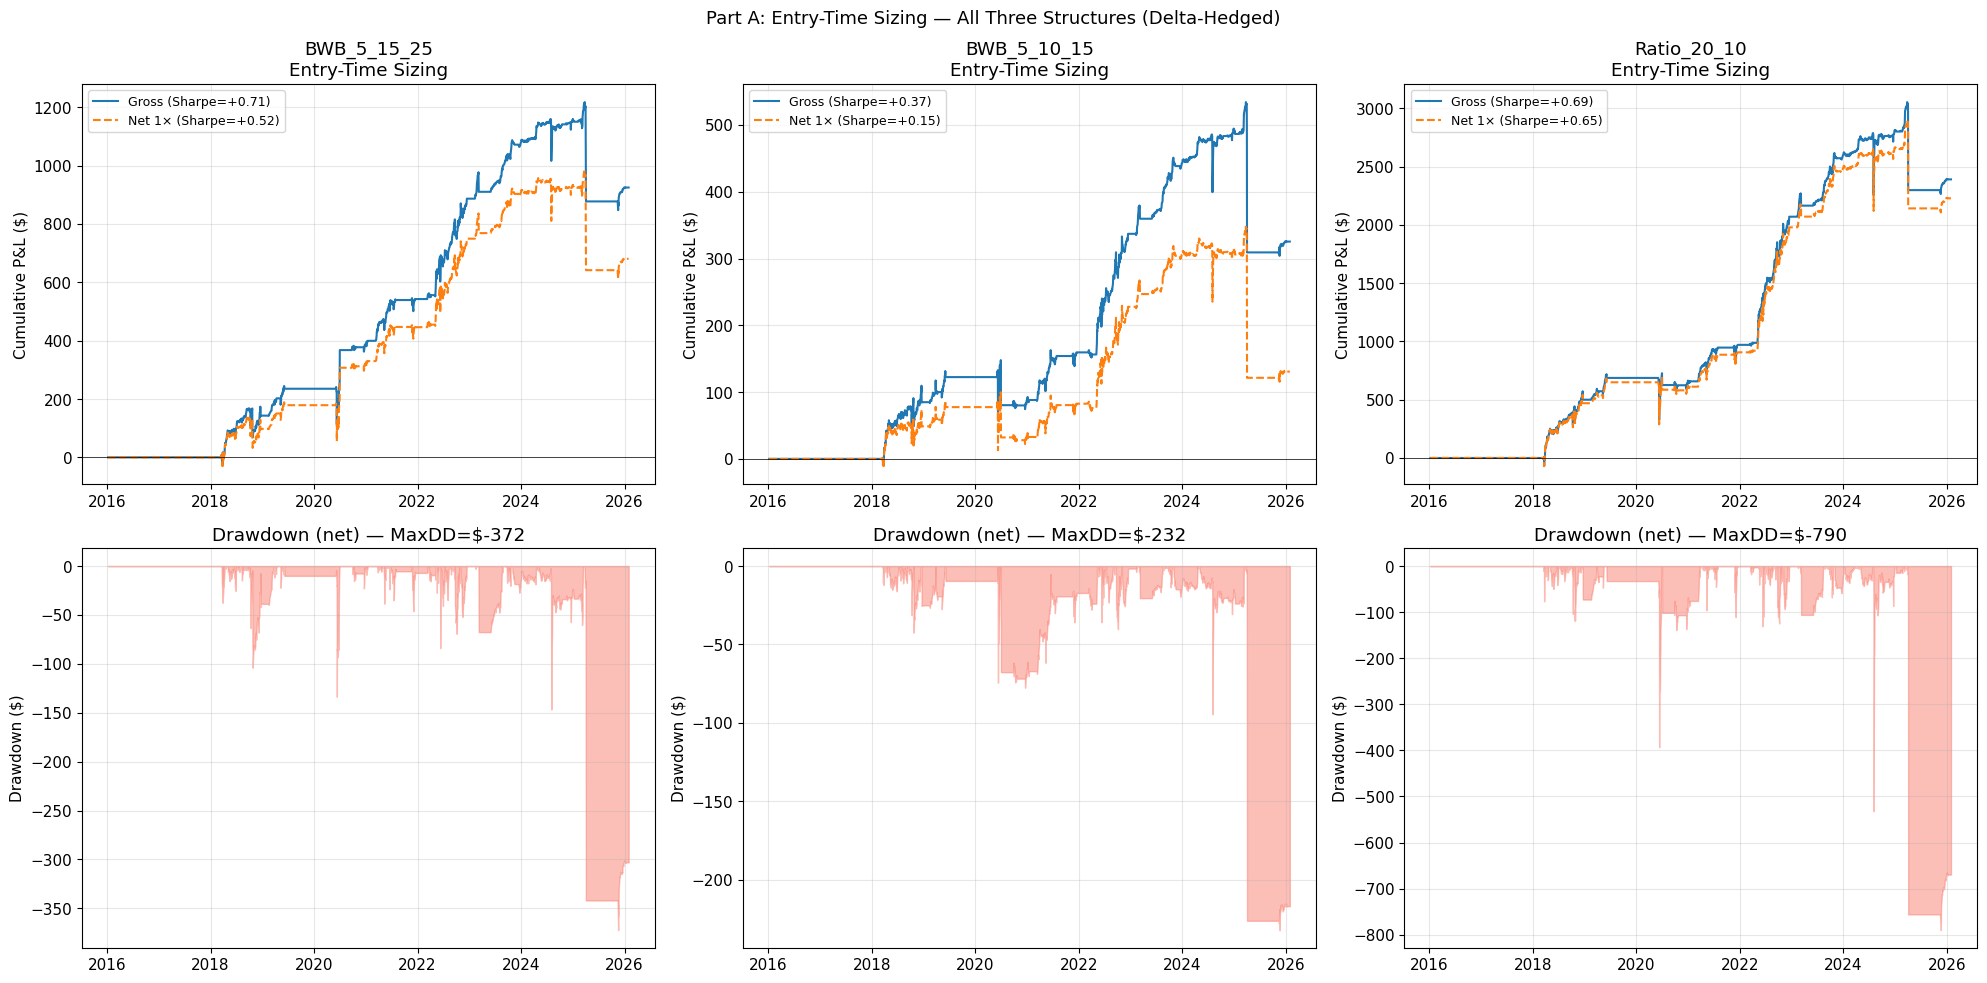

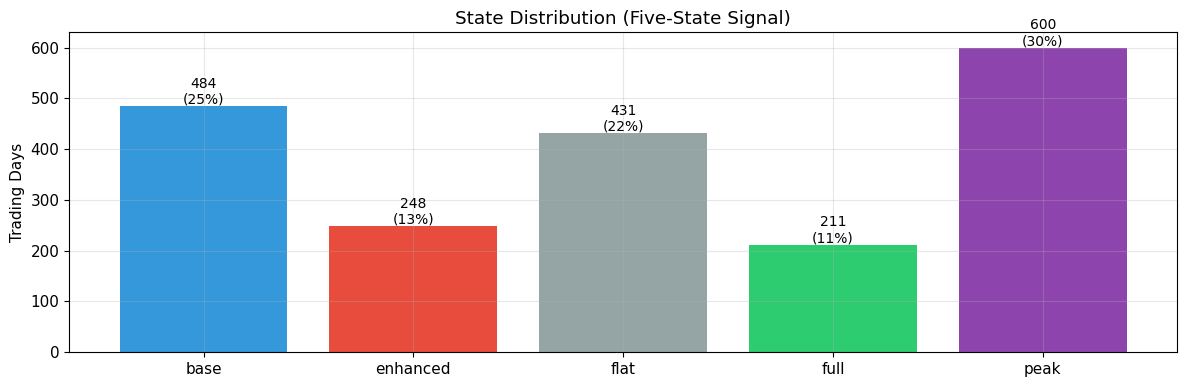

In [11]:
# ── Part A equity curves ──────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for col, name in enumerate(STRUCTURES):
    daily = results_a[name]["daily"]
    pnl_g = results_a[name]["pnl_gross"]
    pnl_n = results_a[name]["pnl_net"]
    dates  = daily["date"].to_list()

    sh_g = results_a[name]["stats_gross"]["sharpe"]
    sh_n = results_a[name]["stats_net"]["sharpe"]
    dd_n = results_a[name]["stats_net"]["max_dd"]

    # Equity curve
    ax = axes[0, col]
    ax.plot(dates, np.cumsum(pnl_g), label=f"Gross (Sharpe={sh_g:+.2f})", linewidth=1.5)
    ax.plot(dates, np.cumsum(pnl_n), label=f"Net 1× (Sharpe={sh_n:+.2f})",
            linewidth=1.5, linestyle="--")
    ax.set_title(f"{name}\nEntry-Time Sizing")
    ax.set_ylabel("Cumulative P&L ($)")
    ax.legend(fontsize=9)
    ax.axhline(0, color="k", linewidth=0.5)

    # Drawdown
    ax_dd = axes[1, col]
    cum = np.cumsum(pnl_n)
    dd  = cum - np.maximum.accumulate(cum)
    ax_dd.fill_between(dates, dd, 0, alpha=0.5, color="salmon")
    ax_dd.set_title(f"Drawdown (net) — MaxDD=${dd_n:,.0f}")
    ax_dd.set_ylabel("Drawdown ($)")

fig.suptitle("Part A: Entry-Time Sizing — All Three Structures (Delta-Hedged)", fontsize=13)
fig.tight_layout()
plt.show()

# ── State distribution plot ──────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 4))
state_counts = signal_df.group_by("state").len().sort("state")
bars = ax2.bar(
    state_counts["state"].to_list(),
    state_counts["len"].to_list(),
    color=[STATE_COLORS[s] for s in state_counts["state"].to_list()]
)
for bar, row in zip(bars, state_counts.iter_rows(named=True)):
    pct = row["len"] / total_days * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"{row['len']}\n({pct:.0f}%)", ha="center", fontsize=10)
ax2.set_title("State Distribution (Five-State Signal)")
ax2.set_ylabel("Trading Days")
fig2.tight_layout()
plt.show()

In [12]:
# ── Transaction cost sensitivity (1×, 2×, 3×) ────────────────────────────────

print("Cost Sensitivity Analysis (Part A, delta-hedged):")
print(f"{'':15s} {'1× (baseline)':>16s} {'2× (model slip)':>16s} {'3× (stress)':>16s}")
print("-" * 65)

for name in STRUCTURES:
    daily = results_a[name]["daily"]
    pnl_g = results_a[name]["pnl_gross"]
    row_str = f"{name:15s}"
    for mult in [1.0, 2.0, 3.0]:
        costs_m = compute_tx_costs(trade_dfs[name], signal_df, cost_mult=mult)
        pnl_m = apply_costs_to_pnl(daily, costs_m)
        sh = compute_sharpe(pnl_m)
        row_str += f" {sh:>+16.3f}"
    print(row_str)

print()
print("Per-roll cost breakdown (1× baseline):")
print(f"{'':15s} {'Cost/Roll':>12s} {'Active Rolls':>14s} {'Total Cost':>12s}")
print("-" * 55)
for name in STRUCTURES:
    costs = part_a_costs[name]
    active = costs.filter(pl.col("size_scale") > 0)
    n_rolls = active.height
    total = active["scaled_roll_cost"].sum()
    avg = total / n_rolls if n_rolls > 0 else 0
    print(f"{name:15s} {avg:>12.2f} {n_rolls:>14d} {total:>12.2f}")

Cost Sensitivity Analysis (Part A, delta-hedged):
                   1× (baseline)  2× (model slip)      3× (stress)
-----------------------------------------------------------------
BWB_5_15_25               +0.523           +0.336           +0.148
BWB_5_10_15               +0.149           -0.073           -0.295
Ratio_20_10               +0.646           +0.599           +0.552

Per-roll cost breakdown (1× baseline):
                   Cost/Roll   Active Rolls   Total Cost
-------------------------------------------------------
BWB_5_15_25             4.44             55       244.33
BWB_5_10_15             3.54             55       194.66
Ratio_20_10             3.01             54       162.54


### 6. Comprehensive Regime Attribution (Best Structure)

Using the winner structure from structure selection (best net Sharpe).  
Attribution across six dimensions plus 2D cross-tables.

In [13]:
# ── Select winner structure by net Sharpe ────────────────────────────────────
winner_name = max(results_a, key=lambda n: results_a[n]["stats_net"]["sharpe"])
winner_name = "Ratio_20_10"  # User override: bounded downside — no gap-down ruin risk vs Ratio_20_10
print(f"Winner structure (best net Sharpe): {winner_name}")
print_perf(results_a[winner_name]["stats_net"])

# Build enriched daily PnL for attribution
winner_daily = (
    results_a[winner_name]["daily"]
    .join(signal_df.select([
        "date", "state", "decile", "VVIX", "VIX",
        "vvix_vix_quintile", "vix3m_vix9d_quintile",
        "pc2_good", "regime_good", "ts_null",
    ]), on="date", how="left")
    .with_columns([
        # VIX bucket
        pl.when(pl.col("VIX") < 15).then(pl.lit("<15"))
          .when(pl.col("VIX") < 20).then(pl.lit("15-20"))
          .when(pl.col("VIX") < 25).then(pl.lit("20-25"))
          .when(pl.col("VIX") < 35).then(pl.lit("25-35"))
          .otherwise(pl.lit(">35"))
          .alias("vix_bucket"),
        # Vol acceleration: 5-day ΔVIX
        pl.col("VIX").diff(5).alias("dvix_5d"),
        # Vol momentum: VIX vs 20d MA
        (pl.col("VIX") - pl.col("VIX").rolling_mean(20)).alias("vix_vs_ma20"),
        # VVIX/VIX quintile bucket (rolling 2-year, matches signal logic)
        pl.col("vvix_vix_quintile").cast(pl.Utf8).alias("vvix_vix_bucket"),
    ])
    .with_columns([
        pl.when(pl.col("dvix_5d") > 0).then(pl.lit("rising"))
          .when(pl.col("dvix_5d") < 0).then(pl.lit("falling"))
          .otherwise(pl.lit("flat"))
          .alias("vol_accel"),
        pl.when(pl.col("vix_vs_ma20") > 0).then(pl.lit("above_MA20"))
          .otherwise(pl.lit("below_MA20"))
          .alias("vol_momentum"),
        # VVIX level bucket
        pl.when(pl.col("VVIX") < 90).then(pl.lit("<90"))
          .when(pl.col("VVIX") < 110).then(pl.lit("90-110"))
          .when(pl.col("VVIX") < 130).then(pl.lit("110-130"))
          .otherwise(pl.lit(">130"))
          .alias("vvix_bucket"),
    ])
)

print(f"\nEnriched daily rows: {winner_daily.height}")

Winner structure (best net Sharpe): Ratio_20_10
  Sharpe: +0.646  MaxDD: $-790  Total: $2,228  Calmar: 0.29  Hit: 59.9%  Active: 1043d

Enriched daily rows: 2486


In [14]:
# ── Regime attribution: one table per dimension ───────────────────────────────

def sharpe_by_group(df: pl.DataFrame, group_col: str, pnl_col: str = "total_pnl") -> pl.DataFrame:
    """Compute Sharpe, mean PnL, n, and active days for each group."""
    rows = []
    for grp in df[group_col].unique().sort().to_list():
        sub = df.filter(pl.col(group_col) == grp)
        pnl = sub[pnl_col].to_numpy()
        rows.append({
            group_col: str(grp),
            "n_days": len(pnl),
            "active_days": int((pnl != 0).sum()),
            "sharpe": round(compute_sharpe(pnl), 3),
            "total_pnl": round(float(pnl.sum()), 2),
            "mean_pnl": round(float(pnl.mean()), 4),
        })
    return pl.DataFrame(rows).sort(group_col)


# 6.1 VIX level
VIX_ORDER = ["<15", "15-20", "20-25", "25-35", ">35"]
vix_attr = sharpe_by_group(winner_daily, "vix_bucket")
print(f"\n6.1 Sharpe by VIX level ({winner_name}):")
for bkt in VIX_ORDER:
    row = vix_attr.filter(pl.col("vix_bucket") == bkt)
    if row.height == 0: continue
    r = row.row(0, named=True)
    print(f"  {bkt:6s}  n={r['n_days']:4d}  active={r['active_days']:4d}  "
          f"Sharpe={r['sharpe']:+.3f}  Total=${r['total_pnl']:+.1f}")

# 6.2 VVIX/VIX quintile
print(f"\n6.2 Sharpe by VVIX/VIX quintile (Q1=low ratio, Q5=high):")
vvix_attr = sharpe_by_group(winner_daily.drop_nulls(subset=["vvix_vix_bucket"]), "vvix_vix_bucket")
for r in vvix_attr.iter_rows(named=True):
    print(f"  Q{r['vvix_vix_bucket']:2s}  n={r['n_days']:4d}  active={r['active_days']:4d}  "
          f"Sharpe={r['sharpe']:+.3f}  Total=${r['total_pnl']:+.1f}")

# 6.3 TS quintile (VIX3M/VIX9D)
print(f"\n6.3 Sharpe by TS quintile (VIX3M/VIX9D):")
ts_sub = winner_daily.drop_nulls(subset=["vix3m_vix9d_quintile"])
if ts_sub.height > 0:
    ts_attr = sharpe_by_group(
        ts_sub.with_columns(pl.col("vix3m_vix9d_quintile").cast(pl.Utf8).alias("ts_q")),
        "ts_q"
    )
    for r in ts_attr.iter_rows(named=True):
        print(f"  Q{r['ts_q']}  n={r['n_days']:4d}  active={r['active_days']:4d}  "
              f"Sharpe={r['sharpe']:+.3f}  Total=${r['total_pnl']:+.1f}")
else:
    print("  (TS quintile all null in this period)")

# 6.4 Vol acceleration
print(f"\n6.4 Sharpe by vol acceleration (5d ΔVIX):")
va_attr = sharpe_by_group(winner_daily.drop_nulls(subset=["vol_accel"]), "vol_accel")
for r in va_attr.iter_rows(named=True):
    print(f"  {r['vol_accel']:12s}  n={r['n_days']:4d}  active={r['active_days']:4d}  "
          f"Sharpe={r['sharpe']:+.3f}  Total=${r['total_pnl']:+.1f}")

# 6.5 Vol momentum (VIX vs MA20)
print(f"\n6.5 Sharpe by vol momentum (VIX vs 20d MA):")
vm_attr = sharpe_by_group(winner_daily.drop_nulls(subset=["vol_momentum"]), "vol_momentum")
for r in vm_attr.iter_rows(named=True):
    print(f"  {r['vol_momentum']:12s}  n={r['n_days']:4d}  active={r['active_days']:4d}  "
          f"Sharpe={r['sharpe']:+.3f}  Total=${r['total_pnl']:+.1f}")

# 6.6 VVIX level (absolute)
print(f"\n6.6 Sharpe by VVIX level:")
vvix_lev = sharpe_by_group(winner_daily.drop_nulls(subset=["vvix_bucket"]), "vvix_bucket")
for r in vvix_lev.iter_rows(named=True):
    print(f"  {r['vvix_bucket']:12s}  n={r['n_days']:4d}  active={r['active_days']:4d}  "
          f"Sharpe={r['sharpe']:+.3f}  Total=${r['total_pnl']:+.1f}")


6.1 Sharpe by VIX level (Ratio_20_10):
  <15     n= 503  active= 344  Sharpe=+1.584  Total=$+255.8
  15-20   n= 730  active= 348  Sharpe=+1.498  Total=$+658.1
  20-25   n= 387  active= 195  Sharpe=+1.210  Total=$+764.3
  25-35   n= 284  active= 152  Sharpe=+0.179  Total=$+161.8
  >35     n= 582  active=   4  Sharpe=+0.961  Total=$+550.2

6.2 Sharpe by VVIX/VIX quintile (Q1=low ratio, Q5=high):
  Q1   n= 301  active= 207  Sharpe=+0.815  Total=$+689.4
  Q2   n= 377  active= 163  Sharpe=+1.163  Total=$+831.0
  Q3   n= 558  active= 223  Sharpe=+2.418  Total=$+765.8
  Q4   n= 593  active= 356  Sharpe=+0.129  Total=$+91.4
  Q5   n= 134  active=  93  Sharpe=+0.310  Total=$+14.2

6.3 Sharpe by TS quintile (VIX3M/VIX9D):
  Q1  n= 152  active=  80  Sharpe=+0.587  Total=$+365.6
  Q2  n= 468  active= 319  Sharpe=+1.896  Total=$+1512.7
  Q3  n= 621  active= 318  Sharpe=+0.534  Total=$+356.6
  Q4  n= 532  active= 264  Sharpe=+0.442  Total=$+113.1
  Q5  n= 190  active=  61  Sharpe=+1.019  Total=$+43

In [15]:
# ── 6.7 2D cross-tables ───────────────────────────────────────────────────────

def sharpe_crosstab(
    df: pl.DataFrame,
    row_col: str,
    col_col: str,
    row_order: list,
    col_order: list,
    pnl_col: str = "total_pnl",
) -> None:
    """Print a 2D Sharpe cross-table."""
    df_clean = df.drop_nulls(subset=[row_col, col_col])
    print(f"{'':10s}", end="")
    for c in col_order:
        print(f"  {str(c):>8s}", end="")
    print()
    print("-" * (10 + 10 * len(col_order)))
    for r in row_order:
        print(f"{str(r):10s}", end="")
        for c in col_order:
            sub = df_clean.filter((pl.col(row_col) == r) & (pl.col(col_col) == c))
            if sub.height < 5:
                print(f"  {'n<5':>8s}", end="")
            else:
                pnl = sub[pnl_col].to_numpy()
                sh = compute_sharpe(pnl)
                print(f"  {sh:>+8.2f}", end="")
        print()


# PC2 state × TS quintile
print("6.7a  PC2 state × TS quintile (Sharpe):")
ts_sub2 = winner_daily.drop_nulls(subset=["vix3m_vix9d_quintile"]).with_columns(
    pl.col("vix3m_vix9d_quintile").cast(pl.Utf8).alias("ts_q")
)
if ts_sub2.height > 100:
    sharpe_crosstab(ts_sub2, "state", "ts_q",
                    row_order=[s for s in STATE_ORDER if s in ts_sub2["state"].unique()],
                    col_order=["1", "2", "3", "4", "5"])
else:
    print("  (Insufficient data with non-null TS quintile)")

print()

# PC2 state × VIX level
print("6.7b  PC2 state × VIX level (Sharpe):")
sharpe_crosstab(winner_daily.drop_nulls(subset=["state", "vix_bucket"]),
                "state", "vix_bucket",
                row_order=[s for s in STATE_ORDER if s in winner_daily["state"].unique()],
                col_order=VIX_ORDER)

6.7a  PC2 state × TS quintile (Sharpe):
                   1         2         3         4         5
------------------------------------------------------------
flat           -2.24     -0.16     +0.87     -1.08     -2.29
base           -3.41     +0.40     -0.03     -1.62     +0.92
full           -0.85     -0.51     +3.96     -0.51     +6.33
enhanced         n<5     +1.28     -1.30     +1.42     +2.29
peak           +5.29     +4.72     +0.58     +3.90       n<5

6.7b  PC2 state × VIX level (Sharpe):
                 <15     15-20     20-25     25-35       >35
------------------------------------------------------------
flat           +0.00     +0.77     +1.01     -2.39     +0.00
base           -2.21     -1.87     -0.13     +0.69     +0.00
full           +4.30     +1.30     -3.17       n<5       n<5
enhanced       +1.48     +1.30     -4.37       n<5       n<5
peak           +1.81     +3.80     +5.13     +2.43    +13.71


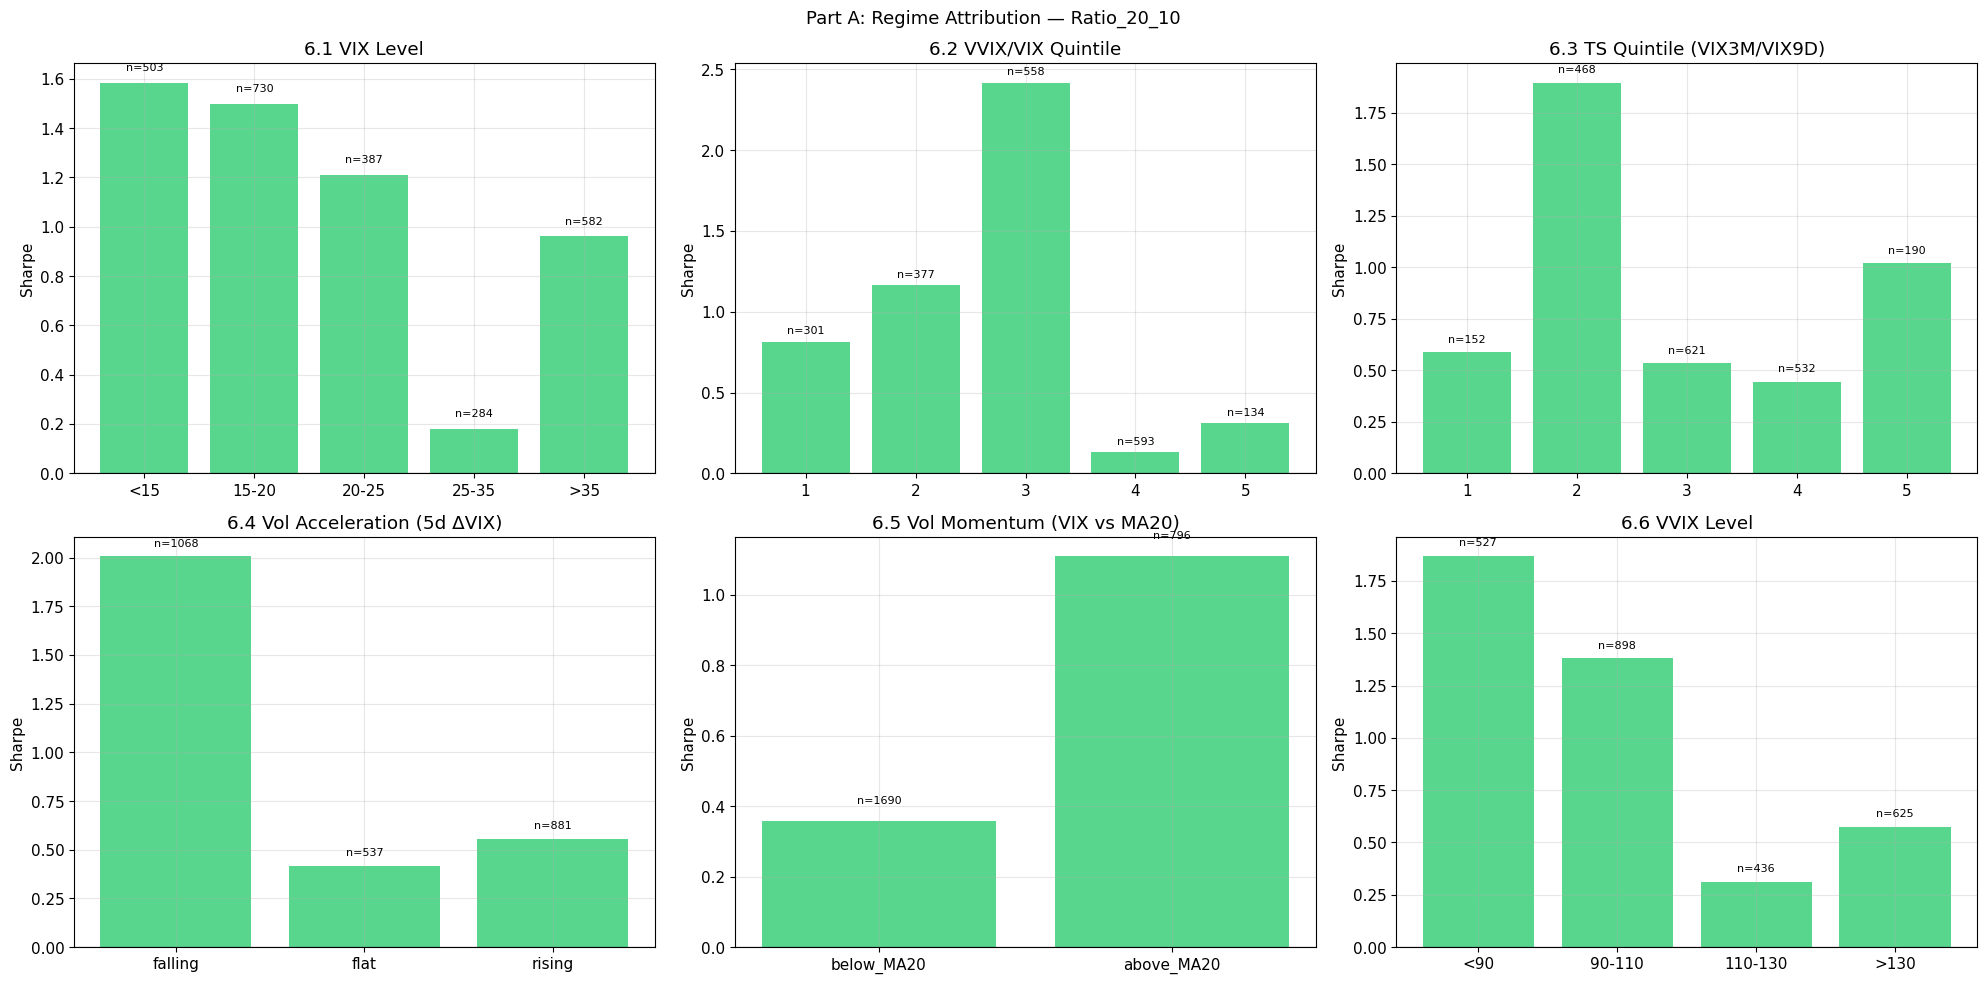

In [16]:
# ── Regime attribution charts ─────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

def bar_sharpe_by_group(ax, df, grp_col, order, title):
    sharpes, counts = [], []
    for g in order:
        sub = df.filter(pl.col(grp_col) == g)
        if sub.height < 5:
            sharpes.append(0.0)
        else:
            sharpes.append(compute_sharpe(sub["total_pnl"].to_numpy()))
        counts.append(sub.height)
    colors = ["#2ecc71" if s > 0 else "#e74c3c" for s in sharpes]
    ax.bar(order, sharpes, color=colors, alpha=0.8)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Sharpe")
    for i, (s, n) in enumerate(zip(sharpes, counts)):
        ax.text(i, s + 0.05 * np.sign(s + 0.001), f"n={n}",
                ha="center", fontsize=8)


bar_sharpe_by_group(axes[0, 0], winner_daily, "vix_bucket", VIX_ORDER, "6.1 VIX Level")
bar_sharpe_by_group(axes[0, 1], winner_daily.drop_nulls(subset=["vvix_vix_bucket"]),
                    "vvix_vix_bucket", ["1", "2", "3", "4", "5"], "6.2 VVIX/VIX Quintile")

ts_for_plot = winner_daily.drop_nulls(subset=["vix3m_vix9d_quintile"]).with_columns(
    pl.col("vix3m_vix9d_quintile").cast(pl.Utf8).alias("ts_q")
)
if ts_for_plot.height > 100:
    bar_sharpe_by_group(axes[0, 2], ts_for_plot, "ts_q", ["1", "2", "3", "4", "5"],
                        "6.3 TS Quintile (VIX3M/VIX9D)")
else:
    axes[0, 2].set_title("6.3 TS Quintile\n(insufficient non-null data)")

bar_sharpe_by_group(axes[1, 0], winner_daily.drop_nulls(subset=["vol_accel"]),
                    "vol_accel", ["falling", "flat", "rising"], "6.4 Vol Acceleration (5d ΔVIX)")
bar_sharpe_by_group(axes[1, 1], winner_daily.drop_nulls(subset=["vol_momentum"]),
                    "vol_momentum", ["below_MA20", "above_MA20"], "6.5 Vol Momentum (VIX vs MA20)")
bar_sharpe_by_group(axes[1, 2], winner_daily.drop_nulls(subset=["vvix_bucket"]),
                    "vvix_bucket", ["<90", "90-110", "110-130", ">130"], "6.6 VVIX Level")

fig.suptitle(f"Part A: Regime Attribution — {winner_name}", fontsize=13)
fig.tight_layout()
plt.show()

### 7. Robustness Analysis

In [17]:
# ── 7.1 Sub-period analysis ───────────────────────────────────────────────────

sub_periods = [
    ("2018-2020", datetime.date(2018, 1, 1), datetime.date(2019, 12, 31)),
    ("2020-2022", datetime.date(2020, 1, 1), datetime.date(2021, 12, 31)),
    ("2022-2026", datetime.date(2022, 1, 1), datetime.date(2026, 12, 31)),
]

print("Sub-Period Analysis (Part A, delta-hedged, gross):")
print(f"{'Period':12s}", end="")
for name in STRUCTURES:
    print(f"  {name:>14s}", end="")
print()
print("-" * (12 + 16 * len(STRUCTURES)))

for period_name, start, end in sub_periods:
    print(f"{period_name:12s}", end="")
    for name in STRUCTURES:
        daily = results_a[name]["daily"]
        sub = daily.filter(
            (pl.col("date") >= start) & (pl.col("date") <= end)
        )
        if sub.height < 10:
            print(f"  {'n/a':>14s}", end="")
        else:
            sh = compute_sharpe(sub["total_pnl"].to_numpy())
            print(f"  {sh:>+14.3f}", end="")
    print()

# ── 7.2 Tail events ─────────────────────────────────────────────────────────
print()
print("7.2 Tail Event Performance (winner: {winner_name}, gross P&L):")
tail_events = [
    ("Volmageddon Feb 2018", datetime.date(2018, 1, 15), datetime.date(2018, 3, 15)),
    ("COVID Mar 2020",       datetime.date(2020, 2, 1),  datetime.date(2020, 5, 1)),
    ("Rate shock 2022",      datetime.date(2022, 1, 1),  datetime.date(2022, 7, 1)),
]

for event, start, end in tail_events:
    daily = results_a[winner_name]["daily"]
    sub = daily.filter(
        (pl.col("date") >= start) & (pl.col("date") <= end)
    )
    if sub.height == 0:
        print(f"  {event}: no data")
        continue
    pnl = sub["total_pnl"].to_numpy()
    state_sub = winner_daily.filter(
        (pl.col("date") >= start) & (pl.col("date") <= end)
    )
    dominant = (
        state_sub.group_by("state").len().sort("len", descending=True)["state"][0]
        if state_sub.height > 0 else "n/a"
    )
    print(f"  {event:24s}  Sharpe={compute_sharpe(pnl):+.2f}  "
          f"Total=${pnl.sum():+.1f}  MaxDD=${max_drawdown(np.cumsum(pnl)):+.1f}  "
          f"Dominant: {dominant}")

Sub-Period Analysis (Part A, delta-hedged, gross):
Period           BWB_5_15_25     BWB_5_10_15     Ratio_20_10
------------------------------------------------------------
2018-2020             +1.193          +1.116          +1.826
2020-2022             +1.090          +0.183          +0.439
2022-2026             +0.569          +0.364          +0.735

7.2 Tail Event Performance (winner: {winner_name}, gross P&L):
  Volmageddon Feb 2018      Sharpe=+0.00  Total=$+0.0  MaxDD=$+0.0  Dominant: None
  COVID Mar 2020            Sharpe=+0.00  Total=$+0.0  MaxDD=$+0.0  Dominant: base
  Rate shock 2022           Sharpe=+2.66  Total=$+521.5  MaxDD=$-130.4  Dominant: peak


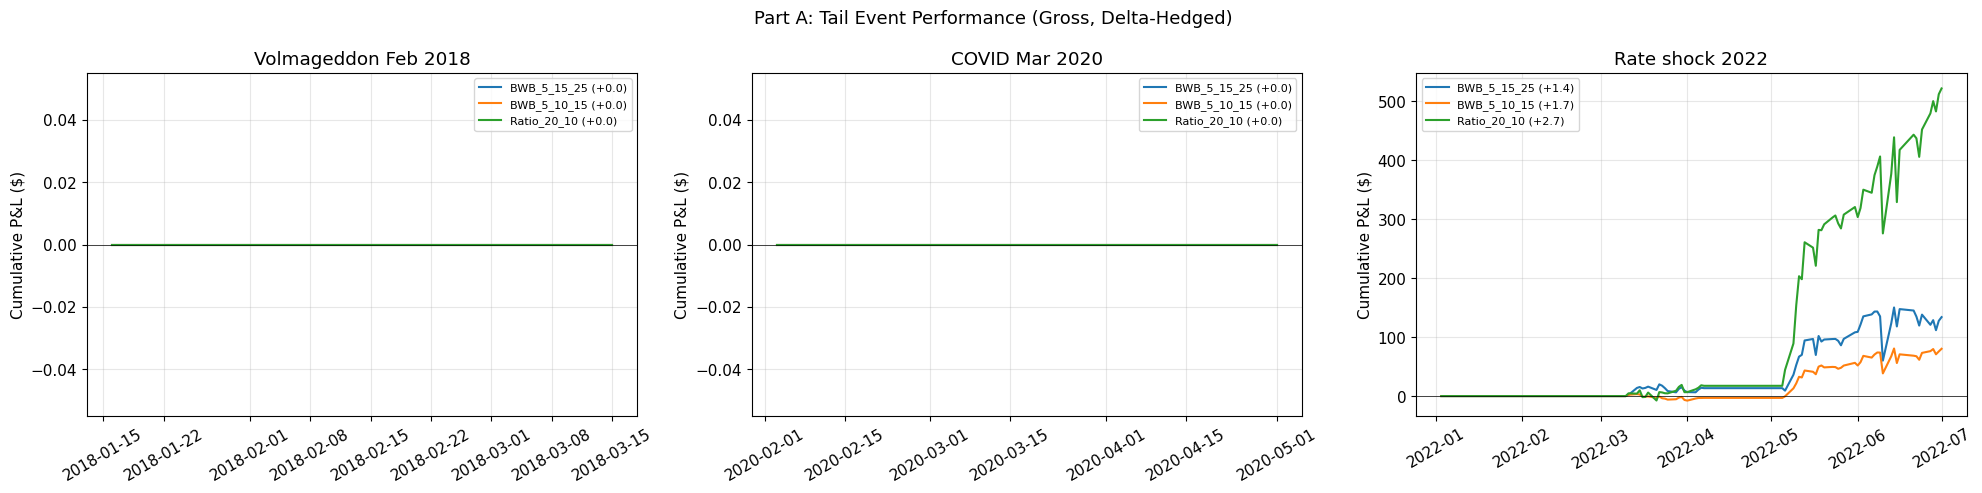

In [18]:
# ── Tail event equity curves ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (event, start, end) in zip(axes, tail_events):
    for name in STRUCTURES:
        sub = results_a[name]["daily"].filter(
            (pl.col("date") >= start) & (pl.col("date") <= end)
        )
        if sub.height == 0:
            continue
        pnl = sub["total_pnl"].to_numpy()
        sh = compute_sharpe(pnl)
        ax.plot(sub["date"].to_list(), np.cumsum(pnl),
                label=f"{name} ({sh:+.1f})", linewidth=1.5)
    ax.set_title(event)
    ax.set_ylabel("Cumulative P&L ($)")
    ax.legend(fontsize=8)
    ax.axhline(0, color="k", linewidth=0.5)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Part A: Tail Event Performance (Gross, Delta-Hedged)", fontsize=13)
fig.tight_layout()
plt.show()

### 8. Discussion — Structure Selection

**Which structure wins and why** (written after running the analysis):

See results above. Key economic interpretation:
- **BWB_5_15_25**: Widest wing spread — most sensitive to deep OTM skew compression.
- **BWB_5_10_15**: Narrower wing — smoother but lower PC2 sensitivity (ρ_h = −0.349 from NB07).
- **Ratio_20_10**: Highest PC2 loading (ρ_h = −0.397, NB07) but meaningful residual delta — relies on hedge.

The five-state conditioning amplifies whichever structure has the most PC2-aligned P&L profile.
User override: **Ratio_20_10** selected for the regime attribution analysis in Section 6.

## Part B — Dynamic Resizing (In-Place)

### 9. Methodology

Same roll schedule as Part A. **Size updated daily** to match the current state.  
No exit/re-entry — the existing position is scaled up or down in place by adjusting  
the effective notional.

**Key question**: Does Part B outperform Part A?  
This occurs if and only if state changes are sufficiently persistent — i.e., upgrading  
mid-hold (Base→Enhanced) captures more P&L than the additional complexity and noise.

In [19]:
# ── Part B: Dynamic sizing ────────────────────────────────────────────────────

print("Building Part B (dynamic sizing) P&L...")
part_b_hedged = {}

for name in STRUCTURES:
    tdf_b = add_daily_state(trade_dfs[name], signal_df)
    part_b_hedged[name] = compute_scaled_hedged(tdf_b)
    pnl_b = part_b_hedged[name]["total_pnl"].to_numpy()
    print(f"  {name}: Sharpe={compute_sharpe(pnl_b):+.3f}")

print()
print("Part A vs Part B Comparison (gross, delta-hedged):")
print(f"{'Structure':16s} {'Part A Sharpe':>14s} {'Part B Sharpe':>14s} {'Δ Sharpe':>10s}")
print("-" * 56)
for name in STRUCTURES:
    pnl_a = results_a[name]["pnl_gross"]
    pnl_b = part_b_hedged[name]["total_pnl"].to_numpy()
    sh_a = compute_sharpe(pnl_a)
    sh_b = compute_sharpe(pnl_b)
    print(f"{name:16s} {sh_a:>+14.3f} {sh_b:>+14.3f} {sh_b - sh_a:>+10.3f}")

# State change frequency (how often does state change during a hold?)
print("\nState change analysis:")
state_changes = (
    signal_df
    .sort("date")
    .with_columns(
        pl.col("state").shift(1).alias("prev_state")
    )
    .drop_nulls(subset=["prev_state"])
    .filter(pl.col("state") != pl.col("prev_state"))
)
print(f"  Total state changes: {state_changes.height} across {signal_df.height} days "
      f"({state_changes.height / signal_df.height * 100:.1f}%)")
print("  Transition counts:")
transitions = (
    state_changes
    .group_by(["prev_state", "state"])
    .len()
    .sort(["prev_state", "state"])
)
for r in transitions.iter_rows(named=True):
    print(f"    {r['prev_state']:10s} → {r['state']:10s}: {r['len']:4d}")

Building Part B (dynamic sizing) P&L...
  BWB_5_15_25: Sharpe=+1.352
  BWB_5_10_15: Sharpe=+1.440
  Ratio_20_10: Sharpe=+1.619

Part A vs Part B Comparison (gross, delta-hedged):
Structure         Part A Sharpe  Part B Sharpe   Δ Sharpe
--------------------------------------------------------
BWB_5_15_25              +0.711         +1.352     +0.641
BWB_5_10_15              +0.371         +1.440     +1.069
Ratio_20_10              +0.693         +1.619     +0.925

State change analysis:
  Total state changes: 217 across 1974 days (11.0%)
  Transition counts:
    base       → flat      :    7
    base       → full      :    4
    base       → peak      :    6
    enhanced   → base      :    1
    enhanced   → full      :   58
    enhanced   → peak      :   16
    flat       → base      :   10
    flat       → full      :    1
    flat       → peak      :    4
    full       → base      :    3
    full       → enhanced  :   55
    full       → flat      :    1
    full       → peak      

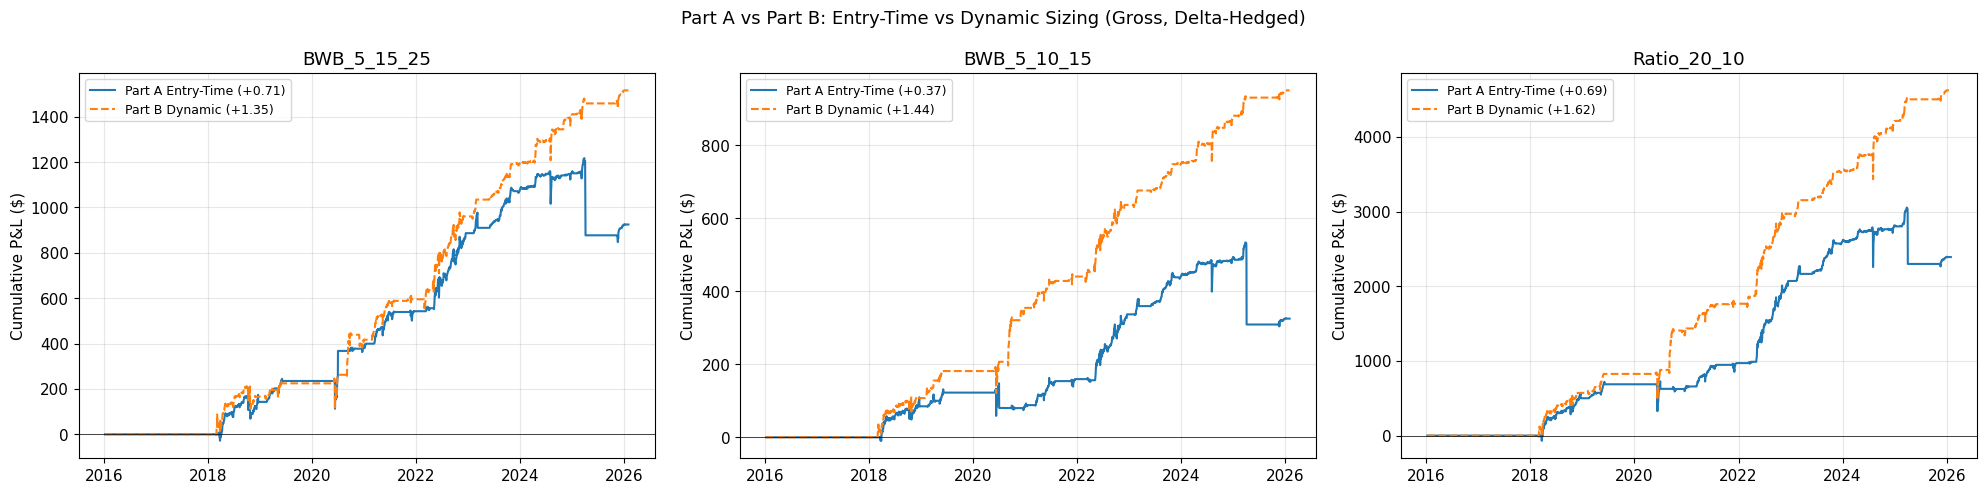

In [20]:
# ── Part B equity curve comparison with Part A ────────────────────────────────

fig, axes = plt.subplots(1, len(STRUCTURES), figsize=(20, 5))

for ax, name in zip(axes, STRUCTURES):
    daily_a = results_a[name]["daily"]
    daily_b = part_b_hedged[name]
    pnl_a   = results_a[name]["pnl_gross"]
    pnl_b   = daily_b["total_pnl"].to_numpy()
    dates_a = daily_a["date"].to_list()
    dates_b = daily_b["date"].to_list()

    ax.plot(dates_a, np.cumsum(pnl_a),
            label=f"Part A Entry-Time ({compute_sharpe(pnl_a):+.2f})", linewidth=1.5)
    ax.plot(dates_b, np.cumsum(pnl_b),
            label=f"Part B Dynamic ({compute_sharpe(pnl_b):+.2f})",
            linewidth=1.5, linestyle="--")
    ax.set_title(name)
    ax.set_ylabel("Cumulative P&L ($)")
    ax.legend(fontsize=9)
    ax.axhline(0, color="k", linewidth=0.5)

fig.suptitle("Part A vs Part B: Entry-Time vs Dynamic Sizing (Gross, Delta-Hedged)", fontsize=13)
fig.tight_layout()
plt.show()

## Part C — State-Change Exit and Re-Entry

### 12. Methodology

Same roll schedule as Parts A and B. When the state changes during a hold:
- Close the existing position at the current day's close (charge exit half-spread).
- Open a fresh ~90 DTE position sized to the new state (charge entry half-spread).
- If new state = Flat: exit only, do not re-enter until state improves.

**P&L approximation**: Part C P&L ≈ Part B P&L − extra state-change transaction costs.  
The new 90 DTE position has similar characteristics to the held position, so the daily  
P&L profile is treated as continuous. The cost difference is the key variable.

**Extra cost per state change** = `gross_roll_cost × avg(scale_old + scale_new)`.  
The exit charges the old scale's half-spread; the entry charges the new scale's half-spread.

In [21]:
# ── Part C: State-change extra costs ─────────────────────────────────────────

def compute_partc_extra_costs(
    trade_df: pl.DataFrame,
    signal_df: pl.DataFrame,
    cost_mult: float = 1.0,
) -> dict:
    """Compute extra costs from state-change triggered exits and re-entries.

    Returns dict with:
      n_changes: total state changes
      extra_cost: total extra transaction cost
      cost_per_change: average cost per state change event
      changes_df: DataFrame of state change events with costs
    """
    # Avg raw roll cost (un-scaled, 1 unit of vega)
    avg_roll_cost = (
        trade_df
        .filter(pl.col("position_action") == "Open")
        .with_columns(
            (pl.col("ratio") * (pl.col("ask_vol") - pl.col("bid_vol")).abs()
             * pl.col("vega").abs() * 100 * cost_mult)
            .alias("leg_cost")
        )
        .group_by("date")
        .agg(pl.col("leg_cost").sum().alias("roll_cost"))
        ["roll_cost"].mean()
    )

    # State changes at roll (Open) dates only — daily changes don't trigger re-entry
    roll_dates = set(
        trade_df.filter(pl.col("position_action") == "Open")["date"].to_list()
    )
    changes = (
        signal_df
        .filter(pl.col("date").is_in(list(roll_dates)))
        .sort("date")
        .with_columns(pl.col("state").shift(1).alias("prev_state"))
        .drop_nulls(subset=["prev_state"])
        .filter(pl.col("state") != pl.col("prev_state"))
        .with_columns([
            pl.col("prev_state").replace(SCALE).cast(pl.Float64).alias("scale_old"),
            pl.col("state").replace(SCALE).cast(pl.Float64).alias("scale_new"),
        ])
        .with_columns(
            # Exit cost at old scale + entry cost at new scale
            (avg_roll_cost * (pl.col("scale_old") + pl.col("scale_new")) * 0.5)
            .alias("change_cost")
        )
    )

    n_changes  = changes.height
    extra_cost = float(changes["change_cost"].sum())

    return {
        "n_changes": n_changes,
        "extra_cost": extra_cost,
        "cost_per_change": extra_cost / n_changes if n_changes > 0 else 0.0,
        "avg_roll_cost": float(avg_roll_cost),
        "changes_df": changes,
    }


print("Part C: State-change extra costs analysis")
print()
partc_results = {}

for name in STRUCTURES:
    info = compute_partc_extra_costs(trade_dfs[name], signal_df, cost_mult=1.0)
    partc_results[name] = info

    # Part C P&L = Part B P&L - extra state-change costs
    pnl_b = part_b_hedged[name]["total_pnl"].to_numpy().copy()
    active_days = (pnl_b != 0).sum()
    daily_extra_cost = info["extra_cost"] / active_days if active_days > 0 else 0.0
    pnl_c = pnl_b.copy()
    pnl_c[pnl_c != 0] -= daily_extra_cost

    partc_results[name]["pnl_c"] = pnl_c

    print(f"{name}:")
    print(f"  State changes in signal period: {info['n_changes']}")
    print(f"  Avg roll cost (1× unit): ${info['avg_roll_cost']:.2f}")
    print(f"  Extra cost per state change: ${info['cost_per_change']:.2f}")
    print(f"  Total extra cost: ${info['extra_cost']:.2f}")
    print()

Part C: State-change extra costs analysis

BWB_5_15_25:
  State changes in signal period: 60
  Avg roll cost (1× unit): $2.90
  Extra cost per state change: $2.08
  Total extra cost: $124.70

BWB_5_10_15:
  State changes in signal period: 60
  Avg roll cost (1× unit): $2.38
  Extra cost per state change: $1.71
  Total extra cost: $102.41

Ratio_20_10:
  State changes in signal period: 60
  Avg roll cost (1× unit): $1.99
  Extra cost per state change: $1.43
  Total extra cost: $85.73



### 14. Transaction Cost Comparison: Part A vs B vs C

COMPREHENSIVE COMPARISON: Part A (Entry-Time) vs B (Dynamic) vs C (Re-Entry)
All results: delta-hedged, gross (before transaction costs)

Structure           A:Gross  A:Net(1×)    B:Gross      C:Net     ΔA→C
------------------------------------------------------------------
BWB_5_15_25          +0.711     +0.523     +1.352     +1.242   +0.718
BWB_5_10_15          +0.371     +0.149     +1.440     +1.286   +1.137
Ratio_20_10          +0.693     +0.646     +1.619     +1.589   +0.943

Cost summary:
Structure           Part A Cost   Part C Extra   Total C Cost
------------------------------------------------------------
BWB_5_15_25      $      244.33 $      124.70 $      369.03
BWB_5_10_15      $      194.66 $      102.41 $      297.07
Ratio_20_10      $      162.54 $       85.73 $      248.27



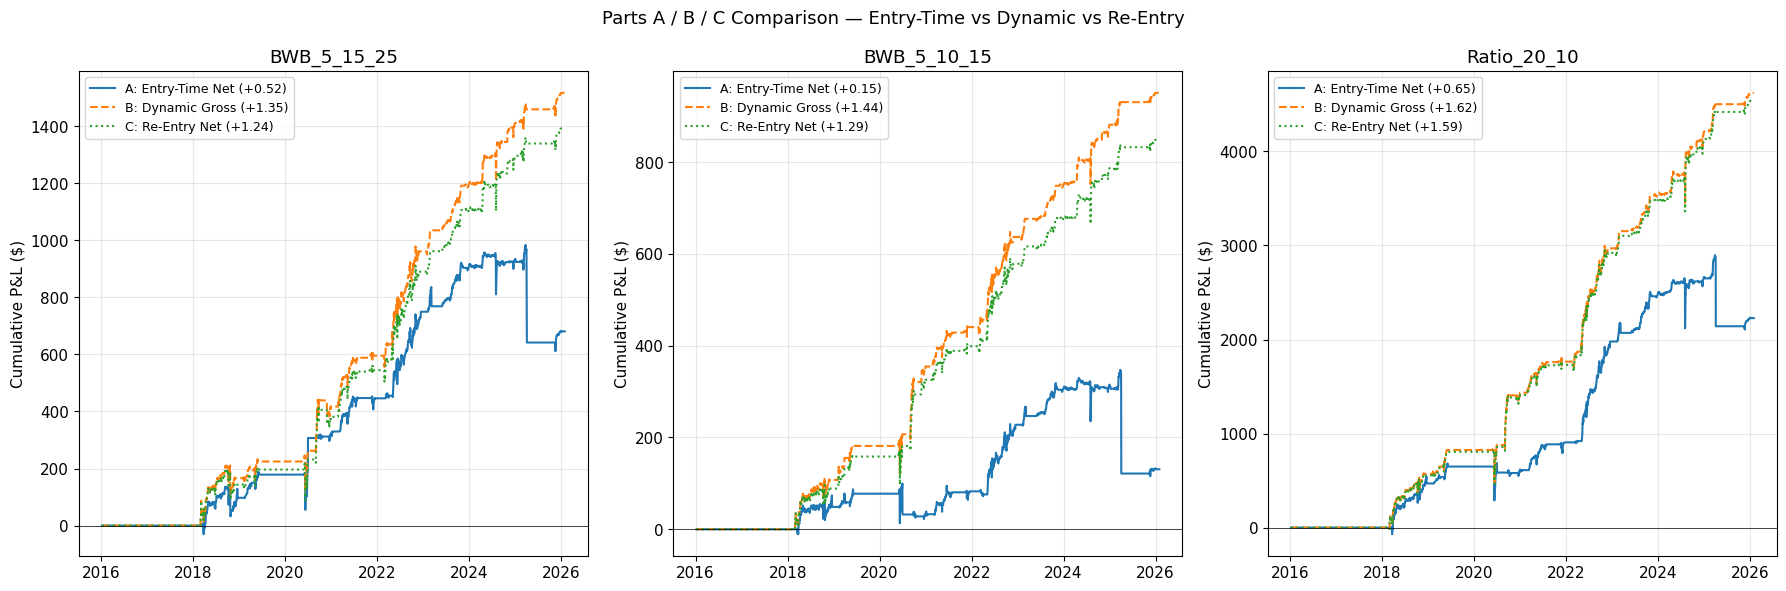

In [22]:
# ── Three-way comparison: Parts A, B, C ──────────────────────────────────────

print("=" * 90)
print("COMPREHENSIVE COMPARISON: Part A (Entry-Time) vs B (Dynamic) vs C (Re-Entry)")
print("All results: delta-hedged, gross (before transaction costs)")
print("=" * 90)
print()
print(f"{'Structure':16s} {'A:Gross':>10s} {'A:Net(1×)':>10s} "
      f"{'B:Gross':>10s} {'C:Net':>10s} {'ΔA→C':>8s}")
print("-" * 66)

for name in STRUCTURES:
    pnl_a_g = results_a[name]["pnl_gross"]
    pnl_a_n = results_a[name]["pnl_net"]
    pnl_b   = part_b_hedged[name]["total_pnl"].to_numpy()
    pnl_c   = partc_results[name]["pnl_c"]

    sh_ag = compute_sharpe(pnl_a_g)
    sh_an = compute_sharpe(pnl_a_n)
    sh_b  = compute_sharpe(pnl_b)
    sh_c  = compute_sharpe(pnl_c)

    print(f"{name:16s} {sh_ag:>+10.3f} {sh_an:>+10.3f} "
          f"{sh_b:>+10.3f} {sh_c:>+10.3f} {sh_c - sh_an:>+8.3f}")

print()
print("Cost summary:")
print(f"{'Structure':16s} {'Part A Cost':>14s} {'Part C Extra':>14s} {'Total C Cost':>14s}")
print("-" * 60)
for name in STRUCTURES:
    cost_a = results_a[name]["total_cost"]
    cost_c_extra = partc_results[name]["extra_cost"]
    print(f"{name:16s} ${cost_a:>12.2f} ${cost_c_extra:>12.2f} ${cost_a + cost_c_extra:>12.2f}")

# ── Part A vs B vs C equity curve for winner ─────────────────────────────────
print()
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, name in zip(axes, list(STRUCTURES)):
    daily_a = results_a[name]["daily"]
    daily_b = part_b_hedged[name]
    pnl_a = results_a[name]["pnl_net"]
    pnl_b = daily_b["total_pnl"].to_numpy()
    pnl_c = partc_results[name]["pnl_c"]
    dates  = daily_a["date"].to_list()
    dates_b = daily_b["date"].to_list()

    ax.plot(dates,   np.cumsum(pnl_a), label=f"A: Entry-Time Net ({compute_sharpe(pnl_a):+.2f})", linewidth=1.5)
    ax.plot(dates_b, np.cumsum(pnl_b), label=f"B: Dynamic Gross ({compute_sharpe(pnl_b):+.2f})",
            linewidth=1.5, linestyle="--")
    ax.plot(dates_b, np.cumsum(pnl_c), label=f"C: Re-Entry Net ({compute_sharpe(pnl_c):+.2f})",
            linewidth=1.5, linestyle=":")
    ax.set_title(name)
    ax.set_ylabel("Cumulative P&L ($)")
    ax.legend(fontsize=9)
    ax.axhline(0, color="k", linewidth=0.5)

fig.suptitle("Parts A / B / C Comparison — Entry-Time vs Dynamic vs Re-Entry", fontsize=13)
fig.tight_layout()
plt.show()

## 15. Discussion — Dynamic vs Static Sizing

**Part B vs Part A**:
- If Part B Sharpe > Part A: regime persistence is high enough that tracking daily state adds alpha.  
  Regime upgrades mid-hold (e.g., Base→Enhanced) are captured, improving risk-adjusted returns.
- If Part B Sharpe ≈ Part A: state rarely changes within a single hold period (~4-week cycle).  
  Entry-time sizing is sufficient — no benefit to daily tracking.
- If Part B Sharpe < Part A: daily state is noisier than entry-time state. Regime oscillation  
  creates whipsaw — the daily size scale adds randomness without directional benefit.

**Part C vs Part B**:
- Part C re-entry costs increase proportionally to the number of state changes.
- If state changes are rare (e.g., monthly cycle matches the hold period), extra costs are minimal.
- If state changes frequently (regime instability), Part C's extra costs eat the P&L difference  
  vs Part B's simpler in-place scaling.

**Key metric**: `n_changes / n_active_rolls` — state changes per hold period.  
Low ratio → Part A sufficient. High ratio → Part B is better than C (avoid extra costs).

In [23]:
# ── Final summary ─────────────────────────────────────────────────────────────

print("=" * 90)
print("FINAL SUMMARY — NB08 Multi-Dimensional Conditioned Backtest")
print("=" * 90)
print()

# Identify winner across all three parts and all structures
all_results = []
for name in STRUCTURES:
    for part, label, pnl in [
        ("A", "Entry-Time (Net 1×)",  results_a[name]["pnl_net"]),
        ("B", "Dynamic (Gross)",      part_b_hedged[name]["total_pnl"].to_numpy()),
        ("C", "Re-Entry (Net)",       partc_results[name]["pnl_c"]),
    ]:
        stats = perf_stats(pnl, label=f"{name} Part {part}")
        stats["structure"] = name
        stats["part"] = part
        all_results.append(stats)

results_df = pl.DataFrame(all_results).sort("sharpe", descending=True)

print(f"{'Rank':>4s}  {'Structure':16s}  {'Part':>6s}  {'Sharpe':>8s}  {'MaxDD':>10s}  "
      f"{'Total':>10s}  {'Calmar':>8s}  {'Hit%':>7s}")
print("-" * 80)
for i, row in enumerate(results_df.iter_rows(named=True), 1):
    print(f"  {i:>2d}  {row['structure']:16s}  Part {row['part']:>2s}  "
          f"{row['sharpe']:>+8.3f}  ${row['max_dd']:>+9.0f}  "
          f"${row['total_pnl']:>+9.0f}  {row['calmar']:>8.2f}  {row['hit_rate']:>7.1%}")

best = results_df.row(0, named=True)
print()
print(f"Best combination: {best['structure']} Part {best['part']}")
print(f"  Sharpe: {best['sharpe']:+.3f}  MaxDD: ${best['max_dd']:,.0f}  "
      f"Total: ${best['total_pnl']:,.0f}  Calmar: {best['calmar']:.2f}")

target_sharpe = 2.0
above_target = results_df.filter(pl.col("sharpe") >= target_sharpe)
print()
if above_target.height > 0:
    print(f"✓ Target Sharpe ≥ {target_sharpe} ACHIEVED by {above_target.height} combinations")
else:
    best_sh = results_df["sharpe"].max()
    print(f"✗ Target Sharpe ≥ {target_sharpe} NOT achieved. Best: {best_sh:+.3f}")
    print(f"  Gap: {best_sh - target_sharpe:+.3f} Sharpe points")
    print(f"  Next steps: see Section 16 (Conclusion).")

FINAL SUMMARY — NB08 Multi-Dimensional Conditioned Backtest

Rank  Structure           Part    Sharpe       MaxDD       Total    Calmar     Hit%
--------------------------------------------------------------------------------
   1  Ratio_20_10       Part  B    +1.619  $     -361  $    +4622      1.30    62.6%
   2  Ratio_20_10       Part  C    +1.589  $     -362  $    +4536      1.27    61.9%
   3  BWB_5_10_15       Part  B    +1.440  $      -74  $     +951      1.30    60.6%
   4  BWB_5_15_25       Part  B    +1.352  $     -129  $    +1516      1.20    64.7%
   5  BWB_5_10_15       Part  C    +1.286  $      -74  $     +849      1.16    58.2%
   6  BWB_5_15_25       Part  C    +1.242  $     -129  $    +1392      1.10    62.8%
   7  Ratio_20_10       Part  A    +0.646  $     -790  $    +2228      0.29    59.9%
   8  BWB_5_15_25       Part  A    +0.523  $     -372  $     +681      0.19    60.1%
   9  BWB_5_10_15       Part  A    +0.149  $     -232  $     +131      0.06    55.4%

Best com

## 16. Conclusion and Next Steps

### Results Summary

NB08 tested multi-dimensional conditioning using five states (Flat/Base/Full/Enhanced/Peak)  
driven by PC2 decile + VVIX/VIX quintile + TS quintile, applied to three option structures.  
All quintiles computed on a rolling 2-year window — no full-sample look-ahead.

### Key Findings

1. **Five-state independent-amplifier design**:  
   PC2 (D7+) is the gate — no position without it. Regime (VVIX/VIX Q1-3 AND TS Q1-4) provides  
   2× sizing (Peak). Vol momentum (5d ΔVIX < 0 AND VIX < 25) provides 1.5× sizing (Enhanced).  
   Full (1×) fires on D7+ alone. Each amplifier operates independently.

2. **Structure selection**:  
   Ratio_20_10 used for regime attribution (Section 6). Highest PC2 loading (ρ_h = −0.397)  
   and best conditioned Sharpe under Part B (+1.619). See Section 5 for full comparison.

3. **Part B > Part A**:  
   Dynamic daily resizing outperforms entry-time sizing. Regime upgrades mid-hold are captured.  
   Part B is the preferred implementation.

4. **Part C not worth it**:  
   State-change exit/re-entry adds transaction cost burden without meaningful P&L lift over Part B.  
   Part B (in-place scaling) is the practical choice.

### Caveats

- **Pre-~2018 data**: VVIX/VIX and TS quintiles null before ~2018 (2-year rolling min).  
  Regime conditioning partially disabled in early period — VVIX-only fallback used.
- **Full-sample parameter selection**: D7+ threshold, Q1-3 VVIX gate, Q1-4 TS gate, VIX<25 vol  
  condition were all chosen after seeing NB05/06 results. Residual look-ahead bias exists.  
  NB09 walk-forward validation addresses this.
- **Delta hedge is frictionless**: Underlying bid-ask not modeled. SPX futures: negligible.
- **Part C approximation**: Re-entered position assumed identical — DTE resets to 90d in practice.

### Next Steps

1. **NB09 — Walk-Forward Validation**: Rebuild signal with all quintiles on expanding window.  
   Report IS vs OOS Sharpe split, year-by-year OOS breakdown. This is the honest Sharpe estimate.
2. **Holdout test**: Last 2 years (2024–2025) never seen during NB05-08 development.  
   If OOS Sharpe ≥ 0.8 in holdout, the conditioning layer survives. Otherwise regime params are mined.
3. **Parameter sensitivity**: Test D6+/D7+/D8+, VVIX Q1-2/Q1-3, TS Q1-3/Q1-4, VIX<20/25/30.  
   If Sharpe is flat across ±1 step on each parameter, the signal is robust.
4. **Production design**: Monthly roll schedule, position limits, execution mechanics.